ข้อมูลดิบ
   │
   ▼
StandardScaler
   │
   ▼
ข้อมูลที่ Scale แล้ว
   │
   ▼
PCA
   │
   ├── PC1
   ├── PC2
   ├── PC3
   └── ...
   │
   ▼
explained_variance_ratio_
   │
   ▼
เลือกจำนวน Component
   │
   ▼
Plot 2D ด้วย PC1 + PC2

In [1]:
import pandas as pd

df = pd.DataFrame({
    "age": [20, 25, 30, 35, 40],
    "income": [15000, 20000, 30000, 50000, 80000],
    "study_hours": [2, 3, 5, 6, 8]
})

ทำ StandardScaler (ถ้าเอาเข้า PCA โดยตรง income มีตัวเลขใหญ่กว่า Feature อื่นมาก PCA อาจให้น้ำหนักกับมันมากเกินไป จึงต้องทำ standardscaler) หลัง Scale แต่ละ Feature จะมีค่าเฉลี่ยประมาณ 0 และ standard deviation ประมาณ 1

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[["age", "income", "study_hours"]]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.41421356 -1.01058231 -1.31122014]
 [-0.70710678 -0.80004433 -0.84292723]
 [ 0.         -0.37896836  0.09365858]
 [ 0.70710678  0.46318356  0.56195149]
 [ 1.41421356  1.72641144  1.4985373 ]]


In [3]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [4]:
print(X_pca.shape)

(5, 3)


explained_variance_ratio  ตัวที่ใช้ในการเลือกจำนวน Component

In [5]:
print(pca.explained_variance_ratio_)

[0.97969192 0.01831797 0.00199011]


In [6]:
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance:.2%}")

PC1: 97.97%
PC2: 1.83%
PC3: 0.20%


PC1              → 97%
PC1 + PC2        → 99%
PC1 + PC2 + PC3  → 100%

In [ ]:
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.97969192 0.99800989 1.        ]


In [10]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(5, 1)


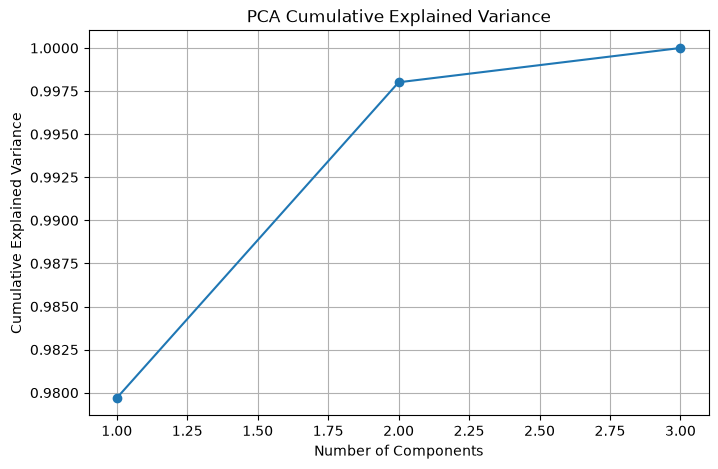

In [11]:
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained) + 1),
    cumulative,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.grid()
plt.show()

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(5, 2)

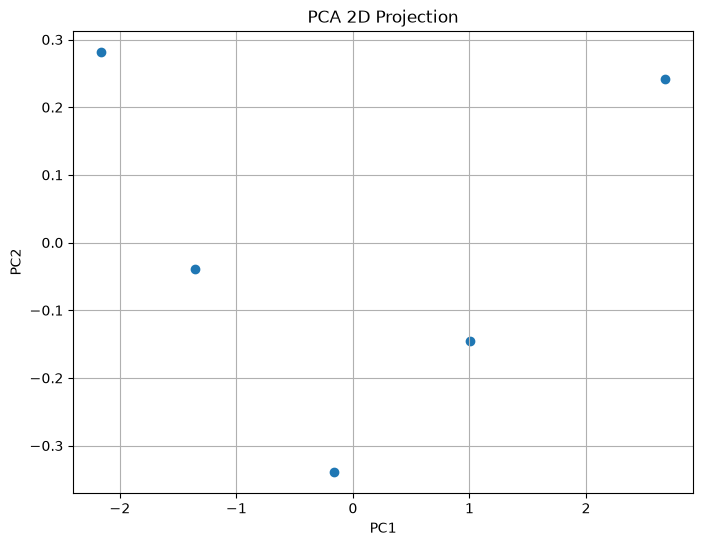

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection")

plt.grid()
plt.show()

In [15]:
X_pca[:, 0]

array([-2.15854023, -1.35679995, -0.16259694,  1.00077757,  2.67715955])

In [16]:
X_pca[:, 1]

array([ 0.28166132, -0.03885341, -0.33888186, -0.14492791,  0.24100186])

X
│
│  Features
│
▼
StandardScaler
│
│  ทำให้แต่ละ Feature อยู่ใน Scale ใกล้กัน
│
▼
PCA
│
│  หาแกนใหม่ PC1, PC2, PC3,...
│
▼
explained_variance_ratio_
│
│  ดูว่าแต่ละ PC เก็บ Variance ได้เท่าไร
│
▼
Cumulative Variance
│
│  เช่น 90%, 95%, 99%
│
▼
เลือกจำนวน Component
│
▼
PCA 2D
│
▼
Plot PC1 vs PC2